# sample1 - Keras 基礎（Sequential API）

TensorFlow / Keras の基本的な使い方を学びます。  
**Sequential API** は層を順番に積み重ねるシンプルなモデル定義方法です。

| ステップ | 内容 |
|----------|------|
| 1 | テンソルの基本 |
| 2 | Sequential API でモデル定義 |
| 3 | model.compile |
| 4 | model.fit で学習 |
| 5 | model.evaluate / predict |

## 0. 警告ログの抑制

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # GPU を無効化して CPU で実行
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
print("TensorFlow バージョン:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

I0000 00:00:1771826588.568792   87060 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1771826589.513655   87060 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow バージョン: 2.22.0-dev20260222
GPU: []


## 1. テンソルの基本

TensorFlow のテンソルは NumPy に似た多次元配列です。

In [2]:
import numpy as np

# テンソルの作成
t1 = tf.constant([1.0, 2.0, 3.0])
t2 = tf.constant([[1, 2], [3, 4]])
t3 = tf.zeros((3, 3))
t4 = tf.random.normal((2, 3))

print("1次元:", t1)
print("2次元:\n", t2)
print("zeros:\n", t3)
print("random:\n", t4)

# NumPy との相互変換
arr = np.array([1.0, 2.0, 3.0])
t5 = tf.constant(arr)           # NumPy → Tensor
arr2 = t5.numpy()               # Tensor → NumPy
print("NumPy → Tensor:", t5)
print("Tensor → NumPy:", arr2)

1次元: tf.Tensor([1. 2. 3.], shape=(3,), dtype=float32)
2次元:
 tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int32)
zeros:
 tf.Tensor(
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]], shape=(3, 3), dtype=float32)
random:
 tf.Tensor(
[[ 2.0066473   0.28682473 -2.4591177 ]
 [ 0.82157755 -0.1752534  -0.40179357]], shape=(2, 3), dtype=float32)
NumPy → Tensor: tf.Tensor([1. 2. 3.], shape=(3,), dtype=float64)
Tensor → NumPy: [1. 2. 3.]


## 2. Sequential API でモデル定義

`tf.keras.Sequential` に層を追加するだけでモデルが定義できます。

In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(4,)),  # 入力4 → 隠れ層16
    tf.keras.layers.Dense(8,  activation='relu'),                    # 隠れ層16 → 隠れ層8
    tf.keras.layers.Dense(3,  activation='softmax')                  # 隠れ層8 → 出力3クラス
])

model.summary()

/home/user/HOME/sample/sample_python/403_TensorFlowKeras/env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

## 3. model.compile

損失関数・オプティマイザ・評価指標を設定します。

In [4]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # 整数ラベルの多クラス分類
    metrics=['accuracy']
)
print("compile 完了")

compile 完了


## 4. model.fit で学習

PyTorch と異なり、学習ループを自分で書く必要がありません。

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X, y = iris.data, iris.target
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,  # 学習データの20%を検証に使う
    verbose=1
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3021 - loss: 1.1062 - val_accuracy: 0.2500 - val_loss: 1.1223
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3750 - loss: 1.0934 - val_accuracy: 0.2917 - val_loss: 1.1092
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4375 - loss: 1.0799 - val_accuracy: 0.3333 - val_loss: 1.0954
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5000 - loss: 1.0649 - val_accuracy: 0.3333 - val_loss: 1.0811
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5625 - loss: 1.0473 - val_accuracy: 0.4167 - val_loss: 1.0655
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6250 - loss: 1.0278 - val_accuracy: 0.4167 - val_loss: 1.0488
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6562 - loss: 1.0061 - val_accuracy: 0.5417 - val_loss: 1.0307
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6667 - loss: 0.9830 - val_accuracy: 0.5417 - val_loss: 1.0111

## 5. model.evaluate / predict / 可視化

In [6]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"テスト Loss    : {loss:.4f}")
print(f"テスト Accuracy: {accuracy:.4f}")

テスト Loss    : 0.0886
テスト Accuracy: 1.0000


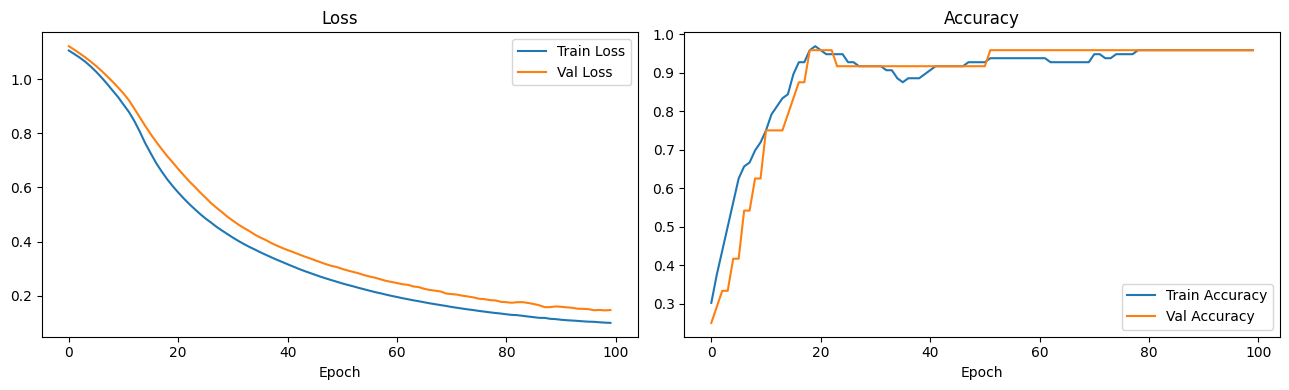

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()